# 06 · K – Wissensextraktion

Vom Modelloutput zum nachvollziehbaren Umzugsaufschlag und Budgetsignal.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## Drei Mietrealitäten

Der Erkenntniswert liegt nicht in einer weiteren „fairen Miete“, sondern in der Trennung von **Bestand 2022**, **Angebotsmarkt Q1/2026** und **persönlicher Situation**. Die Differenz zwischen Bestand und Angebot wird deskriptiv als Umzugsaufschlag bezeichnet.

In [2]:
profiles = pd.read_csv(ROOT / "data/app/region_profiles.csv")
greix = pd.read_csv(ROOT / "data/app/greix_quarterly.csv")
profiles["stock_reference_eur_sqm"] = profiles["stock_2022_age0_size1_eur_sqm"]
profiles["moving_premium_eur_sqm"] = (
    profiles["asking_median_eur_sqm"] - profiles["stock_reference_eur_sqm"]
)
profiles["moving_premium_pct"] = (
    profiles["moving_premium_eur_sqm"] / profiles["stock_reference_eur_sqm"] * 100
)

ranking = profiles[["region", "stock_reference_eur_sqm", "asking_median_eur_sqm",
                    "moving_premium_eur_sqm", "moving_premium_pct"]].sort_values(
                        "moving_premium_pct", ascending=False
                    )
display(ranking.head(12).round(2).style.hide(axis="index"))

region,stock_reference_eur_sqm,asking_median_eur_sqm,moving_premium_eur_sqm,moving_premium_pct
München,10.130000,23.000000,12.870000,127.030000
Bonn,6.260000,13.440000,7.180000,114.690000
Berlin,7.270000,15.500000,8.230000,113.290000
Potsdam,7.120000,14.180000,7.060000,99.230000
Leipzig,5.320000,9.930000,4.610000,86.650000
Augsburg,7.730000,14.410000,6.680000,86.460000
Aachen,6.130000,11.250000,5.120000,83.560000
Bocholt,5.570000,9.690000,4.120000,73.960000
Münster,8.270000,14.000000,5.730000,69.310000
Karlsruhe,7.820000,13.040000,5.220000,66.710000


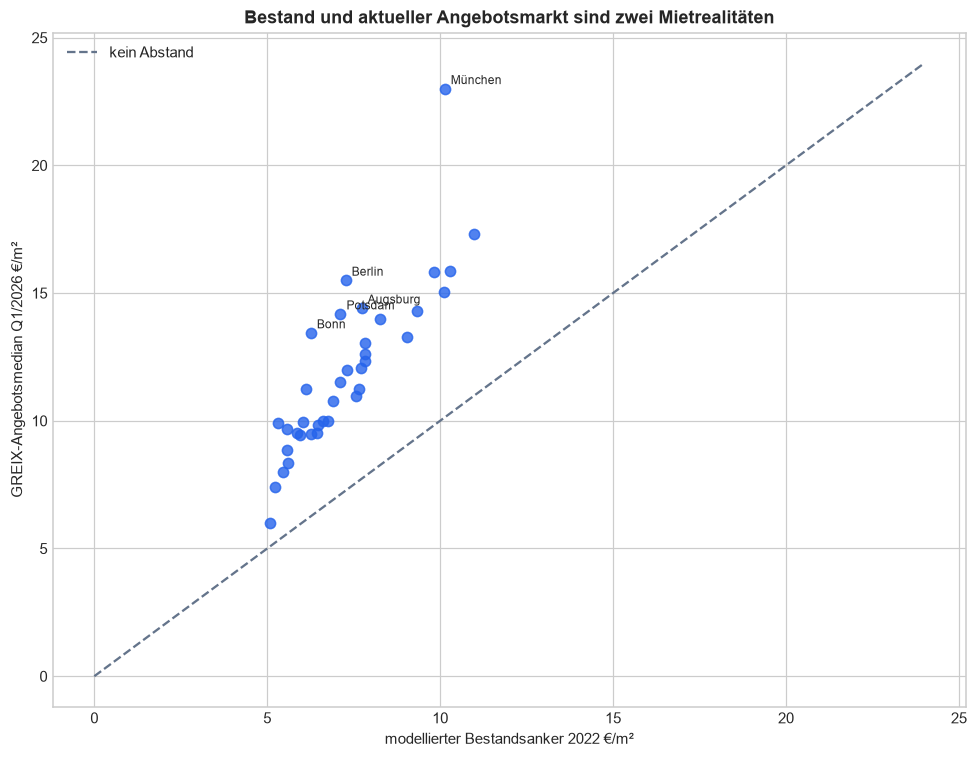

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(profiles["stock_reference_eur_sqm"], profiles["asking_median_eur_sqm"],
           s=45, color=COLORS["blue"], alpha=.8)
limit = max(profiles["asking_median_eur_sqm"].max(), profiles["stock_reference_eur_sqm"].max()) + 1
ax.plot([0, limit], [0, limit], linestyle="--", color=COLORS["grey"], label="kein Abstand")
for _, row in profiles.nlargest(5, "moving_premium_eur_sqm").iterrows():
    ax.annotate(row["region"], (row["stock_reference_eur_sqm"], row["asking_median_eur_sqm"]),
                xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.set(xlabel="modellierter Bestandsanker 2022 €/m²",
       ylabel="GREIX-Angebotsmedian Q1/2026 €/m²",
       title="Bestand und aktueller Angebotsmarkt sind zwei Mietrealitäten")
ax.legend(); plt.tight_layout(); plt.show()

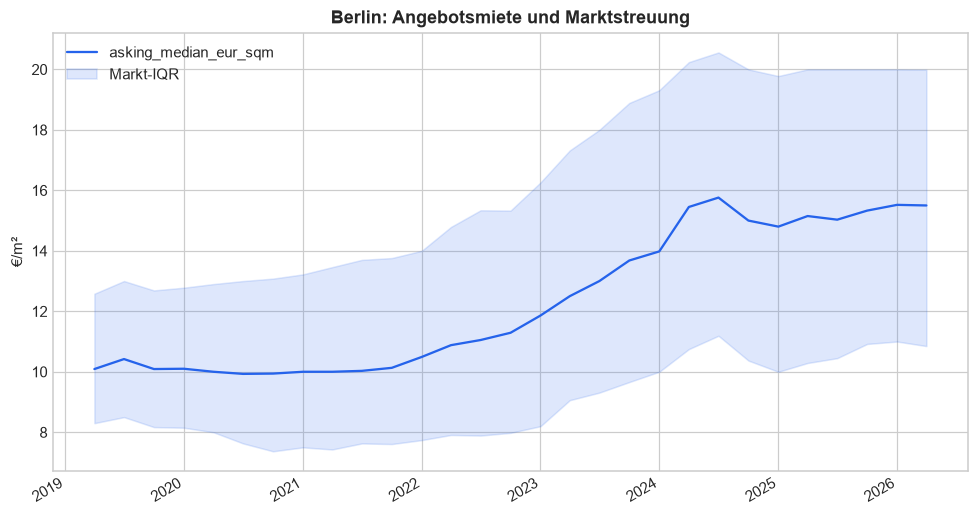

In [4]:
region = "Berlin"
timeline = greix[(greix["region"] == region) & (greix["year"] >= 2019)].copy()
timeline["date"] = pd.PeriodIndex(timeline["period"], freq="Q").to_timestamp(how="end")
ax = timeline.plot(x="date", y="asking_median_eur_sqm", color=COLORS["blue"], legend=False)
ax.fill_between(timeline["date"], timeline["asking_p25_eur_sqm"],
                timeline["asking_p75_eur_sqm"], color=COLORS["blue"], alpha=.15,
                label="Markt-IQR")
ax.set(title=f"{region}: Angebotsmiete und Marktstreuung", xlabel="", ylabel="€/m²")
ax.legend(); plt.tight_layout(); plt.show()

In [5]:
def scenario(region, area_sqm, net_income, current_cold_rent,
                 building_after_1990=False):
    row = profiles.loc[profiles["region"].eq(region)].iloc[0]
    size = int(area_sqm > 65)
    age = int(building_after_1990)
    stock_sqm = row[f"stock_2022_age{age}_size{size}_eur_sqm"]
    half_width = row[f"interval_age{age}_size{size}_half_width_eur_sqm"]
    asking_sqm = row["asking_median_eur_sqm"]
    return pd.Series({
        "Bestandsanker monatlich": stock_sqm * area_sqm,
        "Angebotsmedian monatlich": asking_sqm * area_sqm,
        "aktuelle persönliche Miete": current_cold_rent,
        "Umzugsaufschlag vs. Bestand": (asking_sqm - stock_sqm) * area_sqm,
        "Belastung aktuell": current_cold_rent / net_income,
        "Belastung am Angebotsmedian": asking_sqm * area_sqm / net_income,
        "Modell-Halbbreite monatlich": half_width * area_sqm,
    })

example = scenario("Berlin", area_sqm=70, net_income=3_200, current_cold_rent=850)
display(example.to_frame("Wert").style.format("{:.2f}"))

,Wert
Bestandsanker monatlich,508.69
Angebotsmedian monatlich,1085.00
aktuelle persönliche Miete,850.00
Umzugsaufschlag vs. Bestand,576.31
Belastung aktuell,0.27
Belastung am Angebotsmedian,0.34
Modell-Halbbreite monatlich,162.28


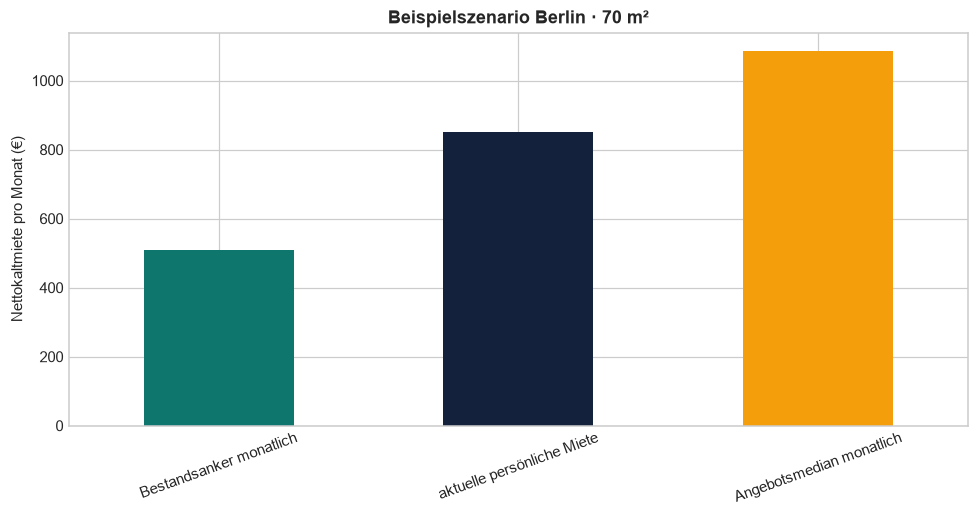

In [6]:
values = example[["Bestandsanker monatlich", "aktuelle persönliche Miete",
                  "Angebotsmedian monatlich"]]
ax = values.plot.bar(color=[COLORS["teal"], COLORS["navy"], COLORS["amber"]], legend=False)
ax.set(title="Beispielszenario Berlin · 70 m²", ylabel="Nettokaltmiete pro Monat (€)", xlabel="")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## Wissensgewinn und Handlungsnutzen

- Der Umzugsaufschlag macht sichtbar, warum Bestandsmietende einen Umzug als wesentlich teurer erleben können.
- Die persönliche Belastung übersetzt €/m² in eine haushaltsnahe Größe, ohne eine starre „leistbar“-Entscheidung vorzugeben.
- Markt-IQR und Modellband beantworten unterschiedliche Fragen und bleiben getrennt.
- München, Berlin und andere angespannte Märkte zeigen große Abstände; dies ist eine deskriptive Beobachtung, keine Kausalbehauptung.
- Nutzerinnen und Nutzer erhalten Datenstand, Quelle, Coverage und Modellgrenzen direkt am Ergebnis.

**Kein Mietspiegel, keine Rechtsberatung, keine individuelle Angebotsprognose.**

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.